In [ ]:
## Take the OBJ files for the differential wall thickness meshes, and determine the thickness along the guard cell

import cross_section_helpers as csh
import importlib
importlib.reload(importlib.import_module("cross_section_helpers"))

inner_mesh = "arabidopsis/Col-0_DA_1_1_P_hinge_CNN_seg_inside.obj"
outer_mesh =  "arabidopsis/Col-0_DA_1_1_P_hinge_CNN_seg_outside.obj"

## Get the cross sections for both the inner and outer meshes
## Calculate the difference between the inner and outer mesh to get the thickness

section_points_inner_left, section_points_inner_right, section_traces_inner_left, section_traces_inner_right = csh.analyze_stomata_mesh(inner_mesh, num_sections=20, n_points=40, visualize=True
)

section_points_outer_left, section_points_outer_right, section_traces_outer_left, section_traces_outer_right = csh.analyze_stomata_mesh(outer_mesh, num_sections=20, n_points=40, visualize=True)


In [7]:
import trimesh

inner_mesh_obj = trimesh.load(inner_mesh)
outer_mesh_obj = trimesh.load(outer_mesh)

csh.visualize_mesh(inner_mesh_obj, section_traces_inner_left + section_traces_inner_right)
csh.visualize_mesh(outer_mesh_obj, section_traces_outer_left + section_traces_outer_right)

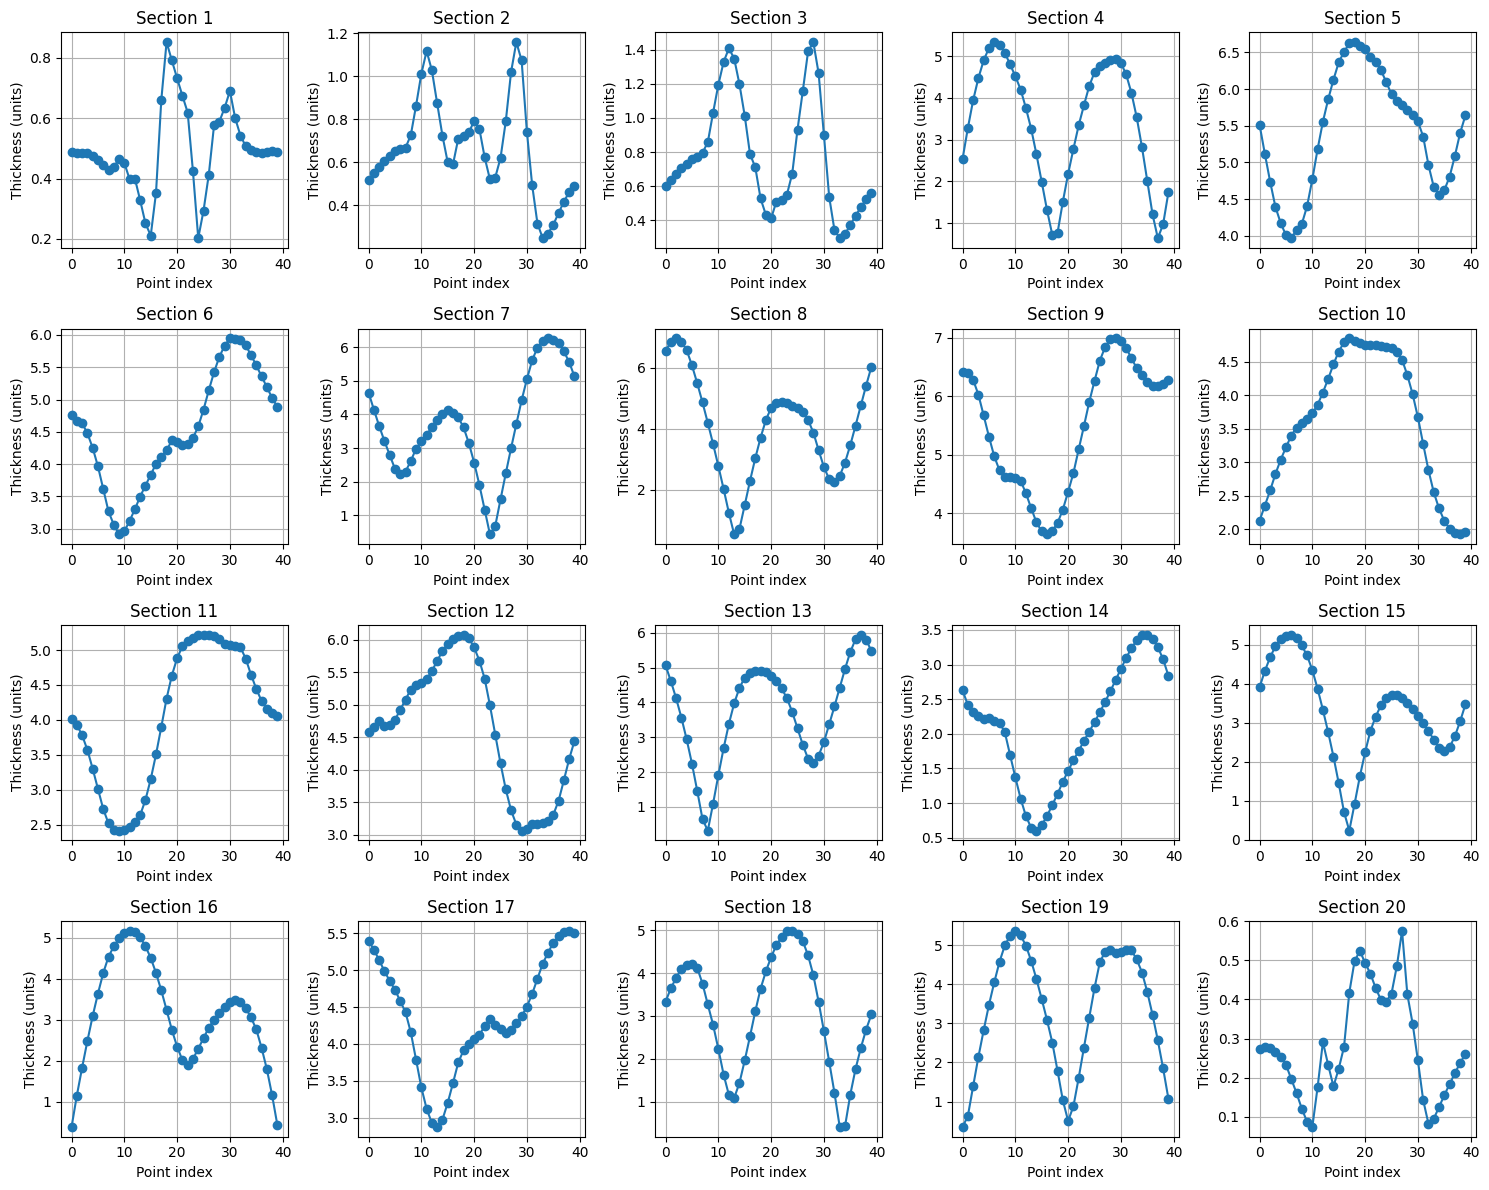

In [9]:
## For inner and outer cross sections, calculate the difference between them

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def resample_section(section, n_points=40):
    """
    Resample a closed 3D curve to n_points equally spaced along its perimeter.
    section: (N, 3) array
    Returns: (n_points, 3) array
    """
    # Compute cumulative distance along the curve
    dists = np.linalg.norm(np.diff(section, axis=0, append=section[:1]), axis=1)
    cumdist = np.concatenate([[0], np.cumsum(dists)])
    total_length = cumdist[-1]
    # Interpolation points
    interp_points = np.linspace(0, total_length, n_points+1)[:-1]
    resampled = []
    for dim in range(3):
        f = interp1d(cumdist, np.append(section[:, dim], section[0, dim]), kind='linear')
        resampled.append(f(interp_points))
    return np.stack(resampled, axis=1)

def compute_thickness_resampled(inner_sections, outer_sections, n_points=40):
    thicknesses = []
    for inner, outer in zip(inner_sections, outer_sections):
        inner_rs = resample_section(inner, n_points)
        outer_rs = resample_section(outer, n_points)
        thickness = np.linalg.norm(outer_rs - inner_rs, axis=1)
        thicknesses.append(thickness)
    return thicknesses

# Compute thickness for left and right guard cells, with resampling
thickness_left = compute_thickness_resampled(section_points_inner_left, section_points_outer_left, n_points=40)
thickness_right = compute_thickness_resampled(section_points_inner_right, section_points_outer_right, n_points=40)

# Plot thickness profiles for each cross section (left cell example)
n_sections = len(thickness_left)
n_cols = 5
n_rows = int(np.ceil(n_sections / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = axes.flatten()

for i, thickness in enumerate(thickness_left):
    ax = axes[i]
    ax.plot(thickness, '-o')
    ax.set_title(f'Section {i+1}')
    ax.set_xlabel('Point index')
    ax.set_ylabel('Thickness (units)')
    ax.grid(True)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

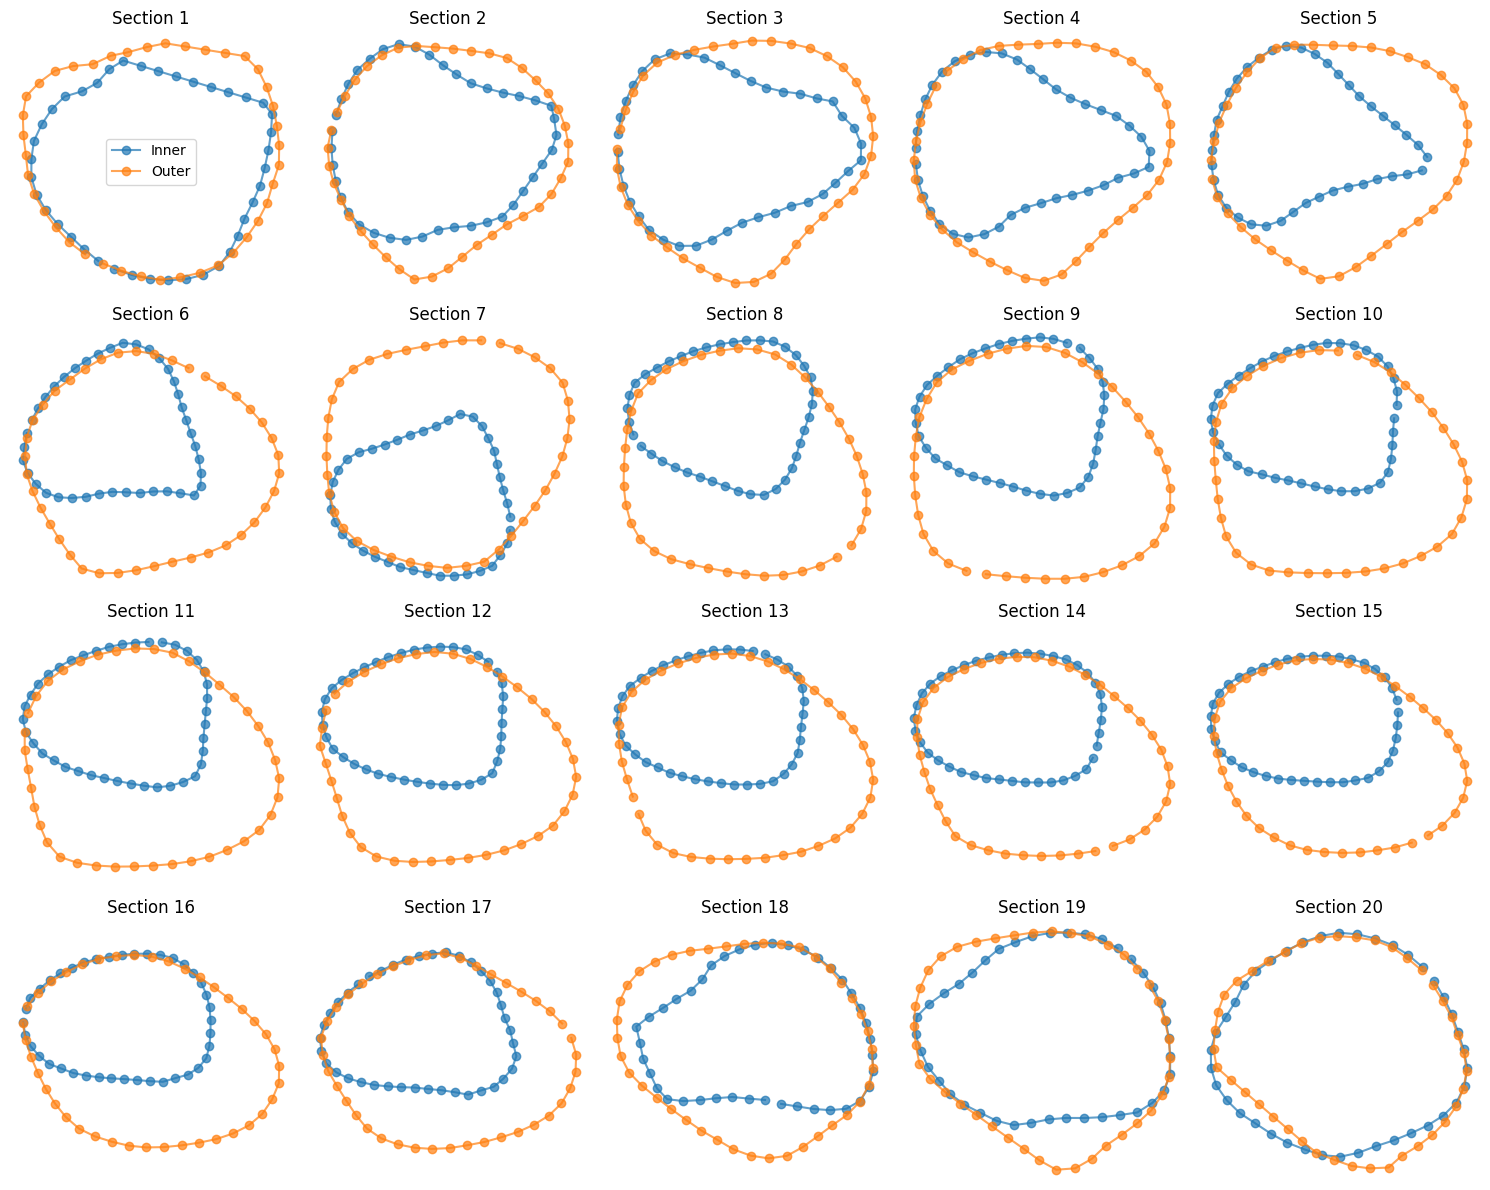

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Overlay inner and outer cross sections for visual inspection
n_sections = len(section_points_inner_left)
n_cols = 5
n_rows = int(np.ceil(n_sections / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = axes.flatten()

for i, (inner, outer) in enumerate(zip(section_points_inner_left, section_points_outer_left)):
    # Resample both to the same number of points
    inner_rs = resample_section(inner, n_points=40)
    outer_rs = resample_section(outer, n_points=40)
    # Project to 2D using PCA (fit on inner)
    pca = PCA(n_components=2)
    inner_2d = pca.fit_transform(inner_rs)
    outer_2d = pca.transform(outer_rs)
    ax = axes[i]
    ax.plot(inner_2d[:, 0], inner_2d[:, 1], '-o', label='Inner', alpha=0.7)
    ax.plot(outer_2d[:, 0], outer_2d[:, 1], '-o', label='Outer', alpha=0.7)
    ax.set_title(f'Section {i+1}')
    ax.axis('equal')
    ax.axis('off')
    if i == 0:
        ax.legend()

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/var/folders/t5/q1tt12hd2sg29kw894zcfbtm000b_5/T/ipykernel_52903/4119248067.py:19: DeprecationWarning:

Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)

/var/folders/t5/q1tt12hd2sg29kw894zcfbtm000b_5/T/ipykernel_52903/4119248067.py:19: DeprecationWarning:

Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)

/var/folders/t5/q1tt12hd2sg29kw894zcfbtm000b_5/T/ipykernel_52903/4119248067.py:19: DeprecationWarning:

Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)

/var/folders/t5/q1tt12hd2sg29kw894zcfbtm000b_5/T/ipykernel_52903/4119248067.py:19: DeprecationWarning:

Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)

/var/folders/t5/q1tt12hd2sg29kw894zcfbtm000b_5/T/ipykernel_52903/4119248067.py:19: DeprecationWarning:



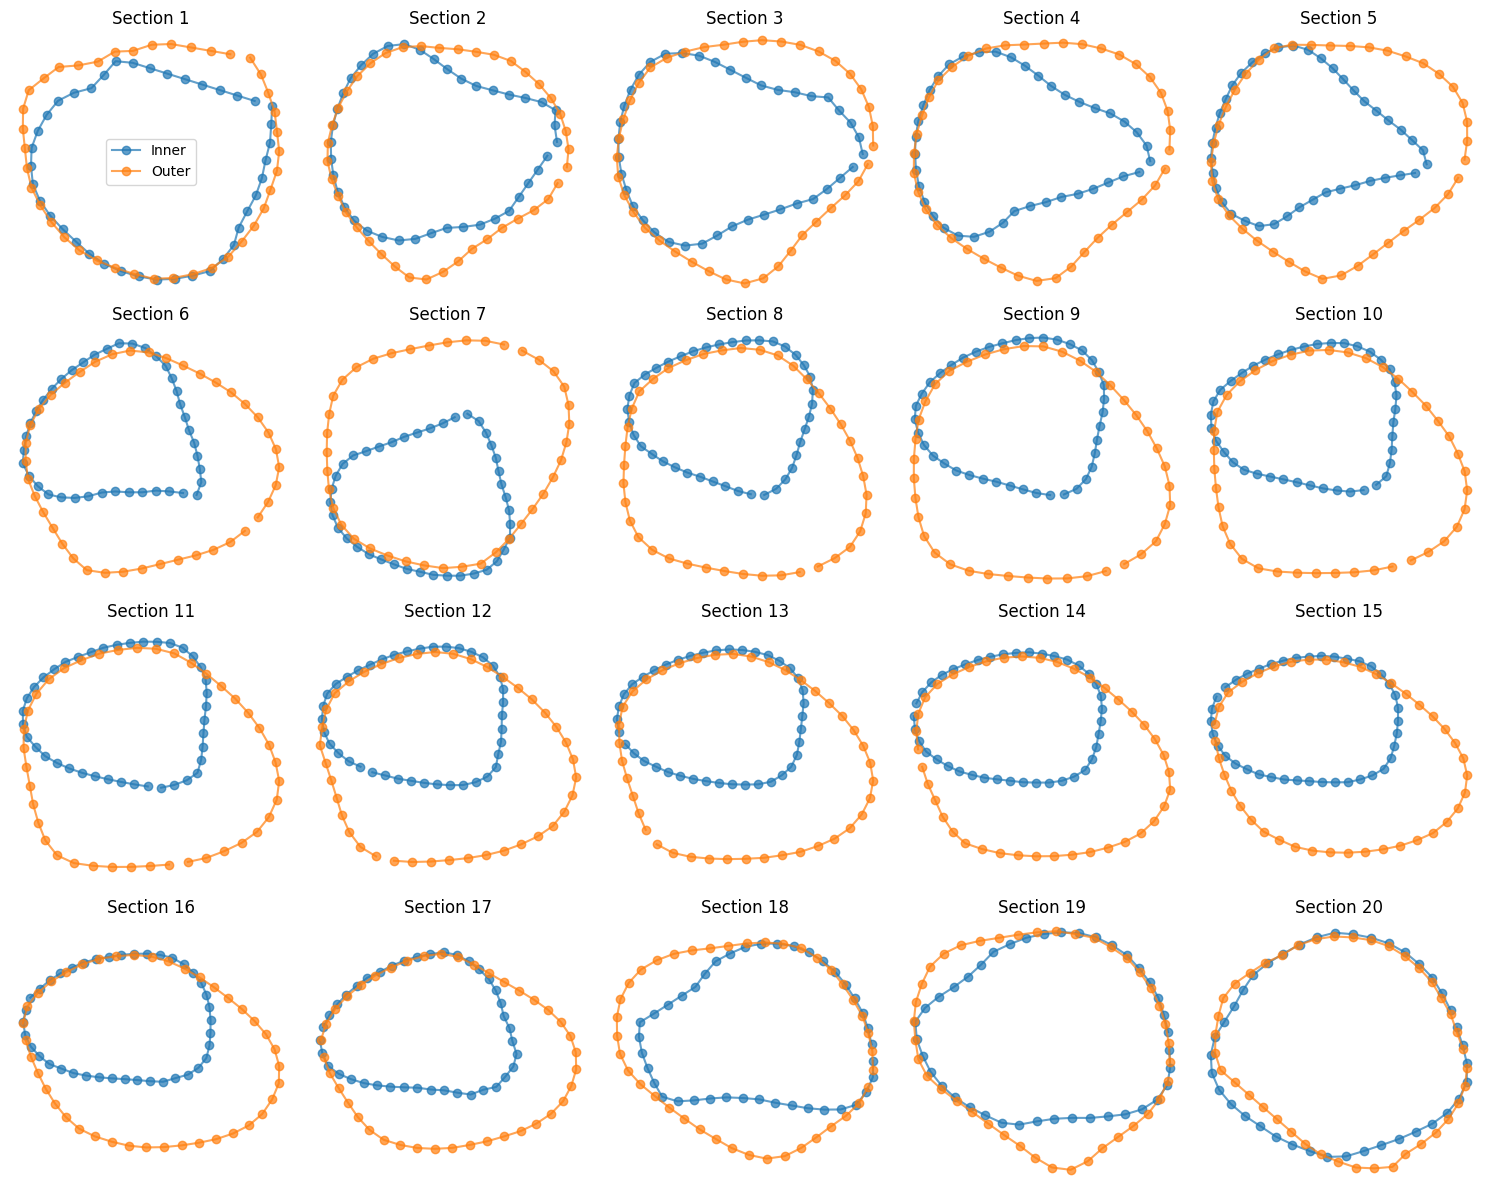

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d

def resample_section_with_direction(section, n_points=40):
    """
    Resample a closed 3D curve to n_points, starting from max x,
    and orient using the direction from max x to max z.
    """
    idx_max_x = np.argmax(section[:, 0])
    idx_max_z = np.argmax(section[:, 2])
    section = np.roll(section, -idx_max_x, axis=0)
    # Vector from max x to max z in the rolled array
    vec = section[idx_max_z] - section[0]
    # Local tangent at start (from first to second point)
    tangent = section[1] - section[0]
    # Use cross product in xz-plane to determine direction
    cross = np.cross(tangent[[0,2]], vec[[0,2]])
    if cross < 0:
        section = section[::-1]
        section = np.roll(section, 1, axis=0)  # keep max x at start
    # Resample as before
    dists = np.linalg.norm(np.diff(section, axis=0, append=section[:1]), axis=1)
    cumdist = np.concatenate([[0], np.cumsum(dists)])
    total_length = cumdist[-1]
    interp_points = np.linspace(0, total_length, n_points+1)[:-1]
    resampled = []
    for dim in range(3):
        f = interp1d(cumdist, np.append(section[:, dim], section[0, dim]), kind='linear')
        resampled.append(f(interp_points))
    return np.stack(resampled, axis=1)

# Overlay using direction-based orientation
n_sections = len(section_points_inner_left)
n_cols = 5
n_rows = int(np.ceil(n_sections / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = axes.flatten()

for i, (inner, outer) in enumerate(zip(section_points_inner_left, section_points_outer_left)):
    inner_rs = resample_section_with_direction(inner, n_points=40)
    outer_rs = resample_section_with_direction(outer, n_points=40)
    # Project to 2D using PCA (fit on inner)
    pca = PCA(n_components=2)
    inner_2d = pca.fit_transform(inner_rs)
    outer_2d = pca.transform(outer_rs)
    ax = axes[i]
    ax.plot(inner_2d[:, 0], inner_2d[:, 1], '-o', label='Inner', alpha=0.7)
    ax.plot(outer_2d[:, 0], outer_2d[:, 1], '-o', label='Outer', alpha=0.7)
    ax.set_title(f'Section {i+1}')
    ax.axis('equal')
    ax.axis('off')
    if i == 0:
        ax.legend()

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
from scipy.interpolate import interp1d

def plane_basis(normal):
    """Return orthonormal (v1,v2) spanning plane perpendicular to normal."""
    normal = np.asarray(normal, dtype=float)
    normal = normal / max(np.linalg.norm(normal), 1e-12)
    ref = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(ref, normal)) > 0.95:
        ref = np.array([1.0, 0.0, 0.0])
    v1 = np.cross(normal, ref)
    n = np.linalg.norm(v1)
    if n < 1e-12:
        raise ValueError("degenerate normal for basis")
    v1 /= n
    v2 = np.cross(normal, v1)
    v2 /= max(np.linalg.norm(v2), 1e-12)
    return v1, v2

def polygon_signed_area_2d(pts2d):
    """Shoelace signed area (positive = CCW)."""
    x = pts2d[:, 0]; y = pts2d[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def resample_closed_curve_2d(pts2d, n_points=40):
    """Resample closed 2D curve given ordered pts2d (assumes first->last are contiguous)."""
    # compute segment lengths
    seg = np.linalg.norm(np.diff(np.vstack([pts2d, pts2d[0]]), axis=0), axis=1)
    cum = np.concatenate([[0.0], np.cumsum(seg)])
    total = cum[-1]
    if total <= 0:
        return np.tile(pts2d[0], (n_points, 1))
    tnew = np.linspace(0, total, n_points+1)[:-1]
    # create interpolation functions for x and y
    x = np.append(pts2d[:, 0], pts2d[0, 0])
    y = np.append(pts2d[:, 1], pts2d[0, 1])
    fx = interp1d(cum, x, kind='linear')
    fy = interp1d(cum, y, kind='linear')
    return np.column_stack([fx(tnew), fy(tnew)])

def resample_section_aligned(
    section3d,
    normal,
    ref_dir_3d=None,
    n_points=40,
    enforce_ccw=True,
    start_by='max_x'   # 'max_x' or 'angle0'
):
    """
    Robust resampling of a closed 3D contour (section3d) lying in a plane with 'normal'.
    Returns resampled 3D points (n_points x 3), ordered consistently:
      - choose start at max in-plane x (v1),
      - ensure CCW winding by default,
      - optionally orient direction to align with ref_dir_3d (3D vector).
    """
    section3d = np.asarray(section3d, dtype=float)
    if section3d.shape[0] < 3:
        raise ValueError("need at least 3 points")
    # origin = centroid (3D)
    origin3 = section3d.mean(axis=0)

    # plane basis
    v1, v2 = plane_basis(normal)

    # project to 2D
    pts2 = np.column_stack([ (section3d - origin3) @ v1, (section3d - origin3) @ v2 ])
    # centroid in-plane
    c2 = pts2.mean(axis=0)

    # order by polar angle around centroid (stable for roughly circular shapes)
    angles = np.arctan2(pts2[:, 1] - c2[1], pts2[:, 0] - c2[0])
    order = np.argsort(angles)
    pts2_ord = pts2[order]
    pts3_ord = section3d[order]

    # ensure closed polygon winding (CCW by default)
    area = polygon_signed_area_2d(pts2_ord)
    if enforce_ccw and area < 0:
        # reverse
        pts2_ord = pts2_ord[::-1]
        pts3_ord = pts3_ord[::-1]
    elif (not enforce_ccw) and area > 0:
        pts2_ord = pts2_ord[::-1]
        pts3_ord = pts3_ord[::-1]

    # choose start index: position of max x (v1) in the ordered array
    if start_by == 'max_x':
        start_idx = int(np.argmax(pts2_ord[:, 0]))
    else:
        # start at smallest angle (optional)
        start_idx = 0

    # roll to start
    pts2_roll = np.roll(pts2_ord, -start_idx, axis=0)
    pts3_roll = np.roll(pts3_ord, -start_idx, axis=0)

    # if a ref_dir_3d is provided, ensure curve runs in direction consistent with it:
    if ref_dir_3d is not None:
        ref = np.asarray(ref_dir_3d, dtype=float)
        # project ref into plane
        ref2 = np.array([ref @ v1, ref @ v2])
        if np.linalg.norm(ref2) > 1e-9:
            # local tangent at start (first -> second) in 2D
            t2 = pts2_roll[1] - pts2_roll[0]
            # 2D cross product (scalar)
            cross = t2[0] * ref2[1] - t2[1] * ref2[0]
            # if cross < 0, the curve goes opposite to ref direction -> reverse
            if cross < 0:
                pts2_roll = pts2_roll[::-1]
                pts3_roll = pts3_roll[::-1]
                # re-roll to keep same start point (since reversing moves start to end)
                pts2_roll = np.roll(pts2_roll, 1, axis=0)
                pts3_roll = np.roll(pts3_roll, 1, axis=0)

    # resample in 2D then map back to 3D
    pts2_rs = resample_closed_curve_2d(pts2_roll, n_points=n_points)
    pts3_rs = origin3[None, :] + pts2_rs[:, 0:1] * v1[None, :] + pts2_rs[:, 1:2] * v2[None, :]

    return pts3_rs


In [20]:
for i, (inner, outer, normal, ref_dir) in enumerate(zip(section_points_inner_left,
                                                         section_points_outer_left,
                                                         normals_list,   # you must provide slice normals or tangents
                                                         ref_dirs_list)): # e.g. seam_dir projected or centreline tangent
    inner_rs = resample_section_aligned(inner, normal, ref_dir_3d=ref_dir, n_points=40)
    outer_rs = resample_section_aligned(outer, normal, ref_dir_3d=ref_dir, n_points=40)
    # project both to same in-plane basis for plotting:
    v1, v2 = plane_basis(normal)
    origin = inner.mean(axis=0)
    inner_2d = np.column_stack([ (inner_rs - origin) @ v1, (inner_rs - origin) @ v2 ])
    outer_2d = np.column_stack([ (outer_rs - origin) @ v1, (outer_rs - origin) @ v2 ])
    ax.plot(inner_2d[:,0], inner_2d[:,1], '-o')
    ax.plot(outer_2d[:,0], outer_2d[:,1], '-o')


NameError: name 'normals_list' is not defined